In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('spotify_tracks.csv')
df = df.drop_duplicates(subset=['track_name','artists'])
features = df[['danceability', 'energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']]
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [4]:
inertia = []
for k in range(2,31):
    model = KMeans(n_clusters=k, random_state=1)
    model.fit_predict(features)
    inertia.append(model.inertia_)

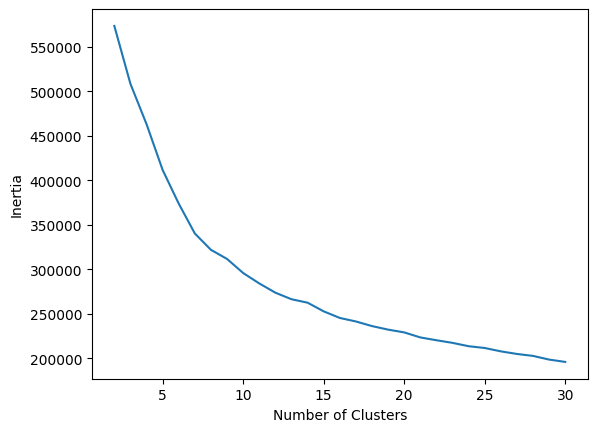

In [5]:
plt.plot(range(2,31), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

Based on this graph, I choose 6 for the number of clusters (k)

In [6]:
model = KMeans(n_clusters=6, random_state=1)
labels = model.fit_predict(features)

In [7]:
df['cluster'] = labels

In [8]:
print(df['cluster'].value_counts())

cluster
2    27528
0    22417
1    17525
3     6687
5     6156
4     1031
Name: count, dtype: int64


In [9]:
print(df.groupby('cluster').mean(numeric_only=True))

         popularity    duration_ms  explicit  danceability    energy  \
cluster                                                                
0         33.887898  253795.355980  0.091092      0.481708  0.815967   
1         35.946419  218749.998802  0.041940      0.540672  0.386461   
2         35.910564  220092.071019  0.116209      0.694687  0.727029   
3         29.150740  229183.993121  0.003290      0.348303  0.183315   
4         24.504365  219337.675073  0.566440      0.571953  0.676994   
5         35.584958  241007.176576  0.061079      0.516213  0.755963   

              key   loudness      mode  speechiness  acousticness  \
cluster                                                             
0        5.351920  -6.055425  0.597984     0.082465      0.058156   
1        5.145563 -10.574772  0.699401     0.056581      0.670231   
2        5.412816  -6.626131  0.608035     0.095696      0.205980   
3        4.914610 -20.975413  0.643637     0.051611      0.834597   
4        

In [10]:
for i in range(6):
    print(f"\nCluster {i}")
    print(df[df["cluster"] == i][["track_name", "artists"]].head(5))


Cluster 0
                                           track_name         artists
40                                          The Haves    Eddie Vedder
44  Speak Your Mind (From the Netflix Series "We T...  Brandi Carlile
52                                             Pieces    Andrew Belle
55                                          The Enemy    Andrew Belle
61                                   Sky's Still Blue    Andrew Belle

Cluster 1
                   track_name                               artists
1            Ghost - Acoustic                          Ben Woodward
2              To Begin Again                Ingrid Michaelson;ZAYN
3  Can't Help Falling In Love                          Kina Grannis
4                     Hold On                      Chord Overstreet
6               Say Something  A Great Big World;Christina Aguilera

Cluster 2
              track_name                    artists
0                 Comedy                Gen Hoshino
5   Days I Will Remember           